In [13]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")
from src.graphs import StaticGraph, DynamicGraph, IntersectingEdgesGraph
from qiskit.quantum_info import Statevector, state_fidelity
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


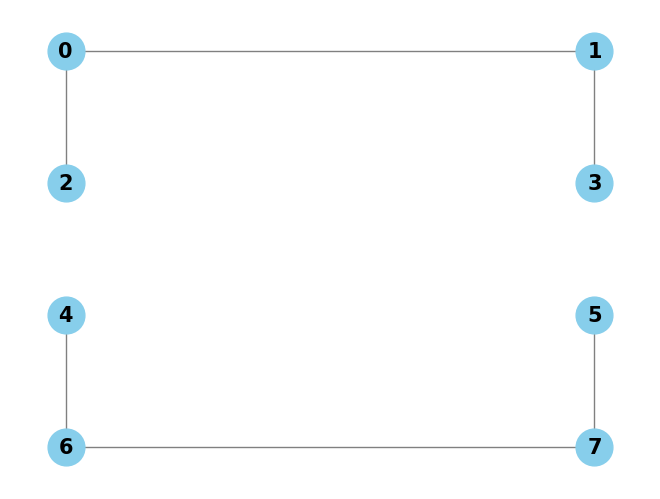

In [14]:
# edges = {('000','010'),
#          ('000','001')}

edges = {('000','010'),
         ('000','001'),
         ('001','011'),
         ('100','110'),
         ('110','111'),
         ('101','111')}

G = StaticGraph(edges)
G.draw()

In [15]:
T = 200
graph_sequence = [(G, T)]
dyn_G = DynamicGraph(graph_sequence)

In [16]:
psi_0 = Statevector.from_label('0'*G.n_qubits)
print('Initial State: ')
psi_0.draw('latex')

Initial State: 


<IPython.core.display.Latex object>

In [17]:
time_evo_op_exact = dyn_G.time_evo_op()
print('Exact Time Evolution Operator: ')
time_evo_op_exact.draw('latex')

Exact Time Evolution Operator: 


<IPython.core.display.Latex object>

In [18]:
psi_target = psi_0.evolve(time_evo_op_exact)
print('Target (Exact) State: ')
psi_target.draw('latex')

Target (Exact) State: 


<IPython.core.display.Latex object>

In [19]:
delta_t = 0.1
t_steps = int(T/delta_t)

StaticGraph(edges={('000', '010'), ('100', '110'), ('101', '111'), ('001', '011')}) | Time = 0.1


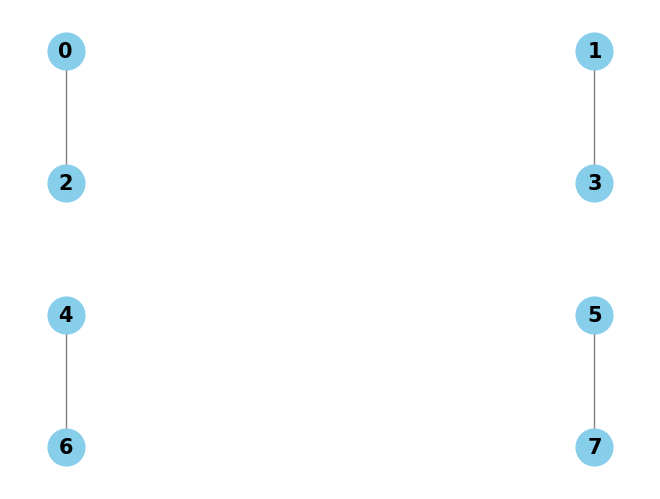

StaticGraph(edges={('000', '001'), ('110', '111')}) | Time = 0.1


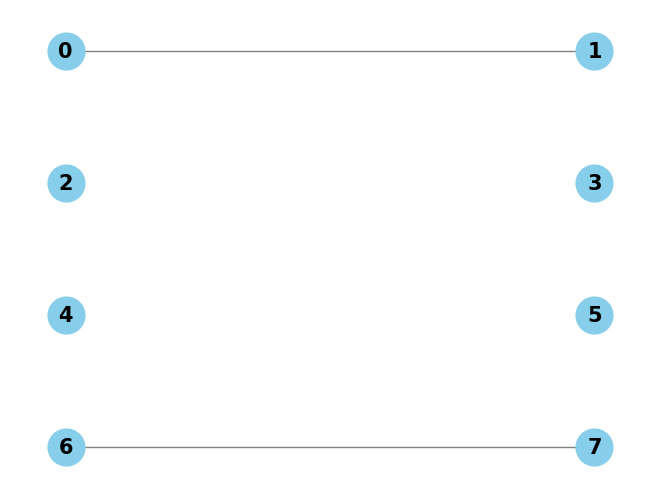

In [20]:
intersecting_G = IntersectingEdgesGraph(edges)
graph_sequence = [(graph, delta_t) for graph in intersecting_G.subgraphs]
dyn_G_approx = DynamicGraph(graph_sequence)
dyn_G_approx.draw()

In [21]:
time_evo_op_approx = dyn_G_approx.time_evo_op(t_steps=t_steps)
print('Approximated Time Evolution Operator: ')
time_evo_op_approx.draw('latex')

Approximated Time Evolution Operator: 


<IPython.core.display.Latex object>

In [22]:
psi_out = psi_0.evolve(time_evo_op_approx)
print('Output (Approximated) State: ')
psi_out.draw('latex')

Output (Approximated) State: 


<IPython.core.display.Latex object>

In [23]:
fid = state_fidelity(psi_out, psi_target)
infid = 1 - fid

print(f'State Infidelity (Difference between Exact State and Approximated State): {round(infid, 3)}')

State Infidelity (Difference between Exact State and Approximated State): 0.006


In [24]:
op_diff = time_evo_op_exact - time_evo_op_approx
op_diff_norm = np.linalg.norm(op_diff.data, ord=2)

print(f'Operator Norm of the Difference between Exact and Approximated Time Evolution Operators: {round(op_diff_norm, 3)}')

Operator Norm of the Difference between Exact and Approximated Time Evolution Operators: 0.078
